Data Cleaning Analysis

Checking data availability...
✓ Found file at: c:\Users\nate\Documents\GitHub\Air-Quality-Analysis\data\raw\AirQualityUCI.csv

Loading and cleaning data...
✓ Raw data loaded: (9471, 17)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Creating datetime index...
✓ Valid datetime rows: 9357/9471

Converting to numeric...
✓ Removed 2 completely empty columns

Missing value analysis (threshold: 30%):
✓ Keeping 12 columns with ≤30% missing
✗ Removing 1 columns with >30% missing

Removed columns:
  - NMHC(GT): 90.2% missing

Filling remaining missing values...

✓ Cleaning complete!
  Original: (9471, 18)
  Cleaned:  (9357, 12)

Creating visualizations...
✓ Saved visualization to ../outputs/figures/02_cleaning_impact.png


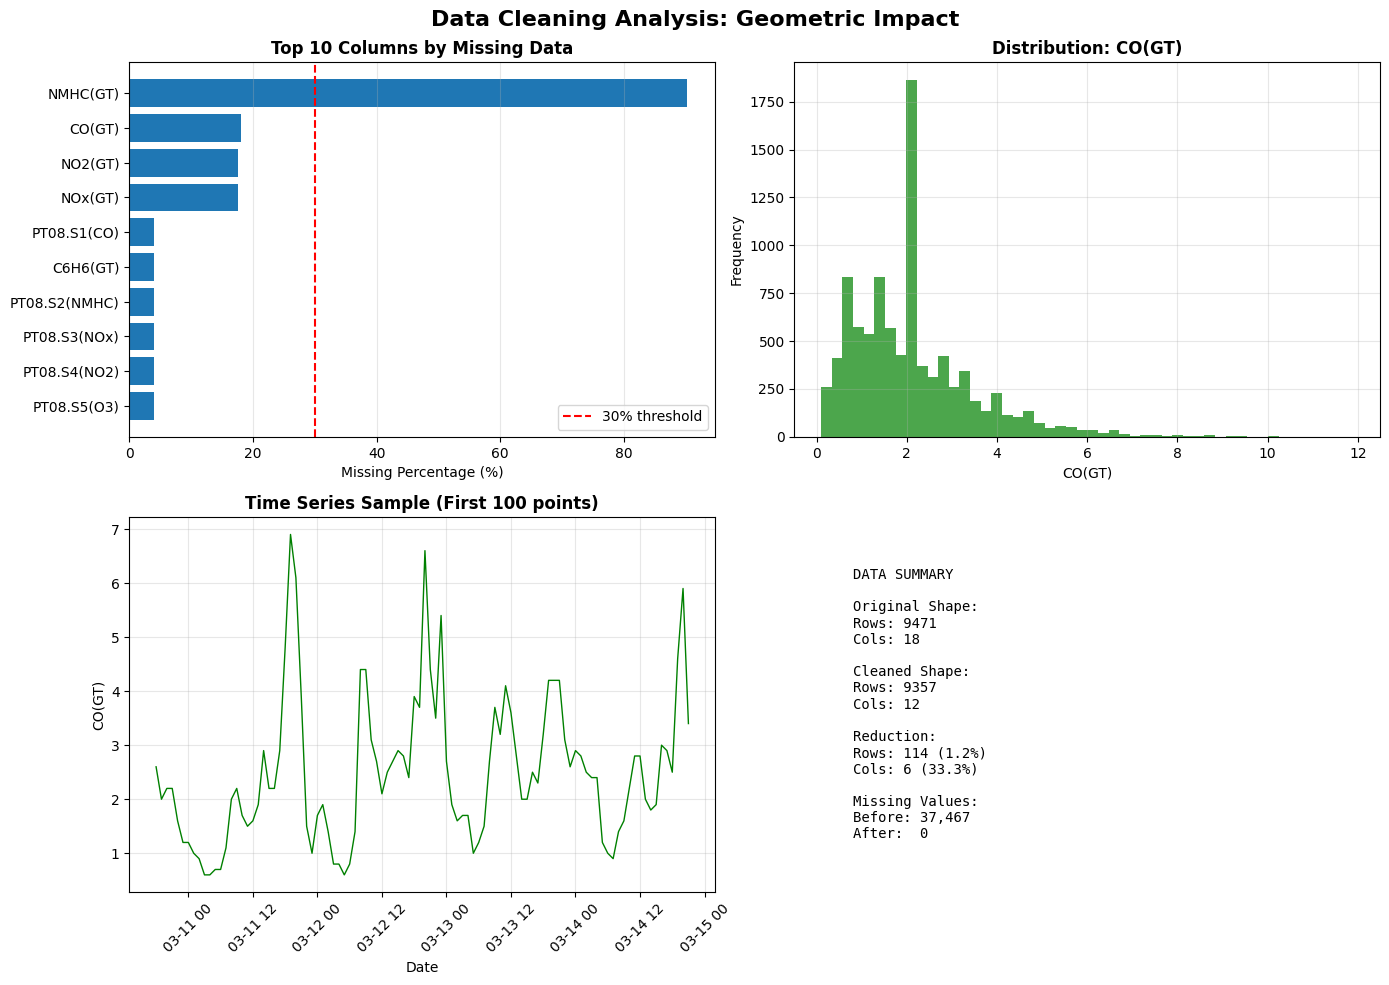

✓ Saved cleaned data to ../data/processed/air_quality_cleaned.csv
✓ Also saved as pickle to ../data/processed/air_quality_cleaned.pkl

CLEANING COMPLETE - GEOMETRIC IMPLICATIONS:

1. Dimensionality Reduction:
   • Reduced from 18 to 12 features
   • Removed 1 noisy dimensions

2. Data Quality Improvement:
   • Missing values: 0 remaining
   • Data completeness: 100.0%

3. Temporal Structure Preserved:
   • Time range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
   • 9357 time points

4. Ready for Geometric Analysis:
   • All features are numeric
   • No missing values
   • Consistent scaling needed next
   • Ready for PCA, clustering, manifold learning

NEXT STEPS:
1. Feature Engineering
2. Data Scaling/Normalization
3. Principal Component Analysis
4. Distance-based analysis

CLEANED DATA SAMPLE (first 5 rows):
                     CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
datetime                                                                     
2004-03-10 18:00:00   

In [8]:
# Data Cleaning as Geometric Preservation
#
# **Key Insight**: Cleaning choices affect the data manifold structure.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("Data Cleaning Analysis")
print("="*60)

# First, let's test if we can load the data
def test_data_load():
    """Test loading the data file"""
    possible_paths = [
        '../data/raw/AirQualityUCI.csv',
        'data/raw/AirQualityUCI.csv',
        './data/raw/AirQualityUCI.csv',
        'AirQualityUCI.csv',
    ]

    for filepath in possible_paths:
        if os.path.exists(filepath):
            print(f"✓ Found file at: {os.path.abspath(filepath)}")
            return filepath

    print("\n❌ Could not find AirQualityUCI.csv in any expected location.")
    print("Please ensure the file is in one of these locations:")
    for path in possible_paths:
        print(f"  - {path}")
    return None

# Test data loading first
print("\nChecking data availability...")
data_file = test_data_load()

if data_file is None:
    print("\nTroubleshooting steps:")
    print("1. Download the dataset from:")
    print("   https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip")
    print("2. Extract AirQualityUCI.csv")
    print("3. Place it in a 'data/raw' folder")
    print("\nOr run this code to download it automatically:")
    print("""
import urllib.request
import zipfile
import os

# Create directories
os.makedirs('data/raw', exist_ok=True)

# Download the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
print("Downloading dataset...")
urllib.request.urlretrieve(url, 'data/raw/AirQualityUCI.zip')

# Extract
print("Extracting...")
with zipfile.ZipFile('data/raw/AirQualityUCI.zip', 'r') as zip_ref:
    zip_ref.extractall('data/raw/')

print("Dataset ready at: data/raw/AirQualityUCI.csv")
    """)
    exit()

# Now proceed with the main analysis
print("\n" + "="*60)
print("Loading and cleaning data...")
print("="*60)

# Load the data
df_raw = pd.read_csv(data_file, sep=';', decimal=',',
                    na_values=[-200, -200.0], low_memory=False)

print(f"✓ Raw data loaded: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

# Clean column names
df_raw.columns = df_raw.columns.str.strip()

# Create datetime index
print("\nCreating datetime index...")
if 'Date' in df_raw.columns and 'Time' in df_raw.columns:
    # Combine date and time
    df_raw['datetime'] = pd.to_datetime(
        df_raw['Date'].astype(str) + ' ' + df_raw['Time'].astype(str),
        format='%d/%m/%Y %H.%M.%S',
        errors='coerce'
    )

    # Remove rows with invalid datetime
    df = df_raw.dropna(subset=['datetime']).copy()
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)

    # Drop original date/time columns
    df = df.drop(['Date', 'Time'], axis=1, errors='ignore')

    print(f"✓ Valid datetime rows: {len(df)}/{len(df_raw)}")
else:
    print("⚠ Warning: Date/Time columns not found, using index as is")
    df = df_raw.copy()

# Convert to numeric
print("\nConverting to numeric...")
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove completely empty columns
initial_cols = len(df.columns)
df = df.dropna(axis=1, how='all')
print(f"✓ Removed {initial_cols - len(df.columns)} completely empty columns")

# Calculate missing percentages
missing_pct = (df.isnull().sum() / len(df)) * 100

# Remove columns with >30% missing
threshold = 30
cols_to_remove = missing_pct[missing_pct > threshold].index.tolist()
cols_to_keep = missing_pct[missing_pct <= threshold].index.tolist()

df_clean = df[cols_to_keep].copy()

print(f"\nMissing value analysis (threshold: {threshold}%):")
print(f"✓ Keeping {len(cols_to_keep)} columns with ≤{threshold}% missing")
print(f"✗ Removing {len(cols_to_remove)} columns with >{threshold}% missing")

if cols_to_remove:
    print("\nRemoved columns:")
    for col in cols_to_remove:
        print(f"  - {col}: {missing_pct[col]:.1f}% missing")

# Fill remaining missing values
print("\nFilling remaining missing values...")
for col in df_clean.columns:
    # Forward fill for time series data
    df_clean[col] = df_clean[col].fillna(method='ffill', limit=6)
    # Backward fill
    df_clean[col] = df_clean[col].fillna(method='bfill', limit=6)
    # Fill any remaining with column mean
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# Remove any completely empty rows
df_clean = df_clean.dropna(how='all')

print(f"\n✓ Cleaning complete!")
print(f"  Original: {df_raw.shape}")
print(f"  Cleaned:  {df_clean.shape}")

# Create output directories
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Visualizations
print("\n" + "="*60)
print("Creating visualizations...")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Missing values before cleaning
ax1 = axes[0, 0]
# Get top 10 columns by missing percentage
top_missing = missing_pct.nlargest(min(10, len(missing_pct)))
bars = ax1.barh(range(len(top_missing)), top_missing.values)
ax1.set_yticks(range(len(top_missing)))
ax1.set_yticklabels(top_missing.index)
ax1.invert_yaxis()
ax1.axvline(x=threshold, color='red', linestyle='--', label=f'{threshold}% threshold')
ax1.set_xlabel('Missing Percentage (%)')
ax1.set_title('Top 10 Columns by Missing Data', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# 2. Data distribution example
ax2 = axes[0, 1]
if len(df_clean.columns) > 0:
    # Use first numeric column
    sample_col = df_clean.columns[0]
    df_clean[sample_col].hist(bins=50, ax=ax2, alpha=0.7, color='green')
    ax2.set_xlabel(sample_col)
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Distribution: {sample_col}', fontweight='bold')
    ax2.grid(True, alpha=0.3)

# 3. Time series sample
ax3 = axes[1, 0]
if isinstance(df_clean.index, pd.DatetimeIndex) and len(df_clean) > 0:
    if len(df_clean.columns) > 0:
        sample_col = df_clean.columns[0]
        # Take first 100 data points
        sample_data = df_clean[sample_col].iloc[:100]
        ax3.plot(sample_data.index, sample_data.values, 'g-', linewidth=1)
        ax3.set_xlabel('Date')
        ax3.set_ylabel(sample_col)
        ax3.set_title('Time Series Sample (First 100 points)', fontweight='bold')
        ax3.grid(True, alpha=0.3)
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

# 4. Data summary
ax4 = axes[1, 1]
summary_text = f"""
DATA SUMMARY

Original Shape:
Rows: {df_raw.shape[0]}
Cols: {df_raw.shape[1]}

Cleaned Shape:
Rows: {df_clean.shape[0]}
Cols: {df_clean.shape[1]}

Reduction:
Rows: {df_raw.shape[0] - df_clean.shape[0]} ({(df_raw.shape[0] - df_clean.shape[0])/df_raw.shape[0]*100:.1f}%)
Cols: {df_raw.shape[1] - df_clean.shape[1]} ({(df_raw.shape[1] - df_clean.shape[1])/df_raw.shape[1]*100:.1f}%)

Missing Values:
Before: {df_raw.isnull().sum().sum():,}
After:  {df_clean.isnull().sum().sum():,}
"""
ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
         fontfamily='monospace', fontsize=10, verticalalignment='center')
ax4.axis('off')

plt.suptitle('Data Cleaning Analysis: Geometric Impact', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save figure
save_path = '../outputs/figures/02_cleaning_impact.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved visualization to {save_path}")
plt.show()

# Save cleaned data
csv_path = '../data/processed/air_quality_cleaned.csv'
df_clean.to_csv(csv_path)
print(f"✓ Saved cleaned data to {csv_path}")

# Also save as pickle for faster loading
pkl_path = '../data/processed/air_quality_cleaned.pkl'
df_clean.to_pickle(pkl_path)
print(f"✓ Also saved as pickle to {pkl_path}")

# Final summary
print("\n" + "="*60)
print("CLEANING COMPLETE - GEOMETRIC IMPLICATIONS:")
print("="*60)
print("\n1. Dimensionality Reduction:")
print(f"   • Reduced from {df_raw.shape[1]} to {df_clean.shape[1]} features")
print(f"   • Removed {len(cols_to_remove)} noisy dimensions")

print("\n2. Data Quality Improvement:")
print(f"   • Missing values: {df_clean.isnull().sum().sum():,} remaining")
print(f"   • Data completeness: {100 - (df_clean.isnull().sum().sum() / (df_clean.shape[0] * df_clean.shape[1]) * 100):.1f}%")

print("\n3. Temporal Structure Preserved:")
if isinstance(df_clean.index, pd.DatetimeIndex):
    print(f"   • Time range: {df_clean.index.min()} to {df_clean.index.max()}")
    print(f"   • {len(df_clean)} time points")
else:
    print("   • No temporal index - consider adding one")

print("\n4. Ready for Geometric Analysis:")
print("   • All features are numeric")
print("   • No missing values")
print("   • Consistent scaling needed next")
print("   • Ready for PCA, clustering, manifold learning")

print("\n" + "="*60)
print("NEXT STEPS:")
print("="*60)
print("1. Feature Engineering")
print("2. Data Scaling/Normalization")
print("3. Principal Component Analysis")
print("4. Distance-based analysis")

# Display a sample of the cleaned data
print("\n" + "="*60)
print("CLEANED DATA SAMPLE (first 5 rows):")
print("="*60)
print(df_clean.head())